# Исследование рынка общественного питания г. Москва

### 01 Цели и задачи проекта

**Цель:** провести исследовательский анализ рынка общественного питания Москвы

**Задачи:**
1. Загрузить данные и познакомиться с их содержанием.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
 - Исследовать количество объектов общественного питания по категориям;
 - Провести анализ распределения заведений по административным районам Москвы;
 - Изучить соотношение сетевых и несетевых заведений;
 - Вывести наиболее типичное количество пасадочных мест для заведений;
 - Изучить рейтинги заведений;
 - Сопоставить рейтинг с остальными данными;
 - Вывести ТОП-15 популярных сетей в Москве;
 - Изучить вариации среднего чека заведений в зависимости от района.
4. Сформулировать выводы по проведенному анализу.

### 03 Содержимое проекта

1. [Загрузка данных и знакомство с ними](#загрузка-данных)
2. [Предобработка данных](#предобработка-данных)
3. [Исследовательский анализ данных](#исследов-анализ)
- 3.1 [Количество заведений по категориям](#количество-заведений)
- 3.2 [Распределение заведений по районам](#распределение-по-районам)
- 3.3 [Соотношение сетевых и несетевых заведений](#соотношение-сетевых)
- 3.4 [Количество посадочных мест](#количество-мест)
- 3.5 [Рейтинги заведений](#рейтинги-заведений)
- 3.6 [Рейтинги и ценовые категории](#рейтинги-цены)
- 3.7 [Популярные сети Москвы](#популярные-сети)
- 3.8 [Средние чеки в заведениях](#средние-чеки)
4. [Итоговый вывод](#итоговый-вывод)
- 4.1 [Основные выводы](#основные-выводы)
- 4.2 [Рекомендации](#рекомендации)

<a id="загрузка-данных"></a>
## 1. Загрузка данных и знакомство с ними

Загрузим библиотеки и датасеты `/datasets/rest_info.csv` и `/datasets/rest_price.csv`. Для анализа данных будем использовать библиотеку **pandas** и библиотеки визуализации **matplotlib** и **seaborn**, для построения матрицы корреляции применим библиотеку **phik**. Данные датасетов сохраним в переменные `rest_info_df` и `rest_price_df`

In [1]:
# Импортируем библиотеку pandas для анализа данных
import pandas as pd

# Загружаем библиотеки matplotlib и seaborn для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку phik для расчёта коэффициента корреляции phi_k
!pip install phik
from phik import phik_matrix

In [2]:
# Выгрузим данные в переменные: rest_info_df и rest_price_df
rest_info_df = pd.read_csv('/datasets/rest_info.csv')
rest_price_df = pd.read_csv('/datasets/rest_price.csv')

Ознакомимся с данныхми датасета `/datasets/rest_info.csv` - выведем общую информацию с помощью метода *info()* и первые строки датасета методом *head()*

In [3]:
rest_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [4]:
rest_info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


Предварительные выводы о датасете **rest_info**:

- Датасет `/datasets/rest_info.csv` содержит **8406 строк** и **9 столбцов**. 
- Названия столбцов приведены к общему стилю. 
- Большая часть данных содержит текстовые значения и хранится в типе данных **object**. 
- Столбцы `rating` и `seats` хранятся в типе **float64**. Для столбца `seats` больше подойдет тип **int**, так как число мест - это всегда целое число 
- Столбец `chain` - в типе данных **int64**. Он показывает значения 1 или 0, в зависимости от того, является ли заведение сетевым - размеренность данных этого столбца можно оптимизировать. 
- **Пропуски** содержатся в столбцах `hours` и `seats`. Остальные столбцы следует проверить на значения-индикаторы, которые укажут на отсутствие данных. 
- Значения в столбцах соответствуют описанию.

Ознакомимся с данныхми датасета `/datasets/rest_price.csv`

In [5]:
rest_price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


In [6]:
rest_price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


Предварительные выводы о датасете **rest_price**:

- Датасет `/datasets/rest_price.csv` содержит **4058 строк** и **5 столбцов**. 
- Названия столбцов приведены к общему стилю snake case. 
- Часть данных содержит текстовые значения и хранится в типе данных **object**. 
- Столбцы `middle_avg_bill` и `middle_coffee_cup` хранятся в типе **float64**. 
- **Пропуски** содержатся во всех столбцах, кроме `id`. 
- Значения в столбцах соответствуют описанию. Но помимо заявленных столбцов, в датасете присутствует столбец `id`, который в дальнейшем потребуется для объединения датасетов

---

### Промежуточный вывод

Первичное знакомство показывает, что данные для анализа предоставлены в небольшом объеме, не превышающим 600 KB. Данные, в большей степени, соответствуют описанию и выглядят корректно, за исключением наличия в `/datasets/rest_price.csv` столбца `id`, о котором не было заявлено. Среди данных много пропусков, требующих обработки. Типы данных - в целом выбраны корректно, но часть требует оптимизации. Сами данные в столбцах могут содержать дубликаты, так как их большая часть с типом object представлена в разном стиле написания. 

### Подготовка единого датафрейма

Соединим данные в один датасет `rest_df`, используя тип присоединения `left` в параметре `how`, чтобы в объединенном датасете оказались полные данные о заведениях.

In [7]:
rest_df = rest_info_df.merge(rest_price_df, on='id', how='left')

In [8]:
rest_df.info()

lens_of_start = len(rest_df)
display(f'Количество строк исходного датафрейма: {lens_of_start}')

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


'Количество строк исходного датафрейма: 8406'

Данные объеденены. Итоговый датасет `rest_df` содержит **8406 строк** и **13 столбцов**

<a id="предобработка-данных"></a>
## 2. Предобработка данных

### Оптимизация типов данных 

Данные столбца `seats` - целочисленные значения, но хранятся в типе `float64` в виде дробного числа. Переведем данные к типу `int`

In [9]:
rest_df['seats'] = rest_df['seats'].astype('int64', errors='ignore')

display(rest_df['seats'].dtypes)

dtype('float64')

Тип данных не изменился из-за наличия пустых значений в данных

Так как все остальные данные датасета хранятся в корректных типах данных, менять их не будем. Но типы данных столбцов `chain` и `rating` можно оптимизировать, с помощью понижения разряда бит

In [10]:
rest_df['chain'] = pd.to_numeric(rest_df['chain'], downcast='integer')
rest_df['rating'] = pd.to_numeric(rest_df['rating'], downcast='float')

In [11]:
display(rest_df[['chain', 'rating']].dtypes)

chain        int8
rating    float32
dtype: object

### Наличие пропусков в данных

Выводим информацию о количестве пропусков в столбцах датафрейма `rest_df`

In [12]:
# Расчитаем абсолютное и относительное количество пропусков, сохранипв в переменные:
abs_count = rest_df.isna().sum()
rel_count = rest_df.isna().sum() / len(rest_df)*100

# Выведем отдельный датафрейм из пар значений: имя столбца - количество пропусков:
missing_values = pd.DataFrame({'column_name': abs_count.index, 
                               'absolute_count': abs_count.values, 
                               'relative_count_in_%': rel_count.values})
# Выводим получившийся датафрейм
display(missing_values)

,column_name,absolute_count,relative_count_in_%
0,id,0,0.000000
1,name,0,0.000000
2,category,0,0.000000
3,address,0,0.000000
4,district,0,0.000000
5,hours,536,6.376398
6,rating,0,0.000000
7,chain,0,0.000000
8,seats,3611,42.957411
9,price,5091,60.563883


**В данных довольно много пропусков.** Большая часть приходится на **данные о ценах и среднем чеке** в заведениях (более 50% данных столбца). Пропуски в этих категориях данных могут быть связаны с отсутствием данных в источнике или техническим сбоем. Этот тип пропусков можно отнести к типу MCAR.

Эти данные понадобятся нам для изучения вариаций среднего чека в заведениях в зависимости от района. Поэтому пустые значения в столбцах **price, avg_bill, middle_avg_bill, middle_coffee_cup** заменим на индикатор **-1** для дальнейшего анализа. 

Аналогично можно поступить со столбцом `seats`, где обнаружено **3611 пропусков, что составляет 42,9%** данных. Пропуски могут быть связаны как с отсутствием данных в источнике и техническим сбоем, так и наличием заведений без сидячих мест (по типу "кофе с собой"). Данную гипотезу можно проверить, исследуя категории заведений. Чтобы сохранить целостность данных заменим пропуски на индикатор **0**.

Пропуски в столбце `hours` **составляют 6%** данных и никак не влияют на дальнейший анализ, поэтому оставим без изменений.

In [13]:
# Заменяем пропуски в столбцах с данными о ценах и среднем чеке  на индикатор -1
rest_df[['price', 'avg_bill', 'middle_avg_bill', 'middle_coffee_cup']] = rest_df[['price', 'avg_bill', 'middle_avg_bill', 'middle_coffee_cup']].fillna(-1)

# Заменяем пропуски столбца seats на индикатор 0 и меняем тип данных на integer
rest_df['seats'] = rest_df['seats'].fillna(0)
rest_df['seats'] = rest_df['seats'].astype('int64', errors='ignore')

# Выводим тип данных для проверки
display(f'Тип данных столбца seats: {rest_df["seats"].dtypes}')

'Тип данных столбца seats: int64'

In [14]:
# Выводим количество пропусков во всех столбцах после обработки:
display(rest_df.isna().sum())

id                     0
name                   0
category               0
address                0
district               0
hours                536
rating                 0
chain                  0
seats                  0
price                  0
avg_bill               0
middle_avg_bill        0
middle_coffee_cup      0
dtype: int64

### Явные и неявные дубликаты в данных

Проверяем данные на наличие явных и неявных дубликатов.

In [15]:
# Проверим наличие полных дубликатов в датафрейме rest_df
rest_df.duplicated().sum()

0

В датафрейме нет явных дубликатов строк. Проверим неявные дубликаты

In [16]:
# Выведем количество уникальных значений каждого столбца
display(rest_df.nunique())

id                   8406
name                 5614
category                8
address              5753
district                9
hours                1307
rating                 41
chain                   2
seats                 229
price                   5
avg_bill              898
middle_avg_bill       231
middle_coffee_cup      97
dtype: int64

Количество уникальных значений `id` совпадает с количеством строк датафрейма. Следовательно, все значения `id` уникальны.

In [17]:
# Проверяем уникальные значения в столбцах с небольшим числом уникальных значений
for column in ['category', 'district', 'chain']:
    display(f'Уникальные значения в столбце {column}:')
    display(rest_df[column].sort_values().unique())
    display()

'Уникальные значения в столбце category:'

array(['бар,паб', 'булочная', 'быстрое питание', 'кафе', 'кофейня',
       'пиццерия', 'ресторан', 'столовая'], dtype=object)

'Уникальные значения в столбце district:'

array(['Восточный административный округ',
       'Западный административный округ',
       'Северный административный округ',
       'Северо-Восточный административный округ',
       'Северо-Западный административный округ',
       'Центральный административный округ',
       'Юго-Восточный административный округ',
       'Юго-Западный административный округ',
       'Южный административный округ'], dtype=object)

'Уникальные значения в столбце chain:'

array([0, 1], dtype=int8)

Так как в файле есть сетевые заведения, они будут содержать одинаковое имя, но разный адрес. Проверим, есть ли в списке дублирующиеся по имени и адресу заведения.

In [18]:
# Все значения столбцов name и address приведем к нижнему регистру
rest_df['name'] = rest_df['name'].str.lower()
rest_df['address'] = rest_df['address'].str.lower()

In [19]:
# Проверим есть ли заведения с одинаковым названием и адресом в датафрейме
duplicates = rest_df[rest_df.duplicated(subset=['name', 'address'], keep=False)]
display(duplicates)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 09:00–23:00",3.2,0,0,-1,-1,-1.0,-1.0
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,0,0,-1,-1,-1.0,-1.0
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188,-1,-1,-1.0,-1.0
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188,-1,-1,-1.0,-1.0
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",Северо-Восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150,-1,-1,-1.0,-1.0
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150,-1,-1,-1.0,-1.0
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",Западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276,-1,-1,-1.0,-1.0
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",Западный административный округ,NaN,4.1,0,276,-1,-1,-1.0,-1.0


Всего выявлено 4 дубликата по названию и адресу заведения. Они различаются часами работы и принадлежностью к сетевым заведениям. Предположим, что более поздняя запись является наиболее актуальной. Оставим только последнюю внесенную запись.

In [20]:
# Удалим дубликаты за исключением последней записи 
rest_df = rest_df.drop_duplicates(subset=['name', 'address'], keep='last')

Для дальнейшей работы создаем столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [21]:
# Выведем значения столбца hours
display(rest_df['hours'].sort_values().unique())

array(['Нет информации',
       'вт 08:30–17:00; ср,чт 12:00–20:30; пт 08:30–17:00; сб 09:00–16:30',
       'вт 13:00–21:00; ср 11:00–20:00; чт 13:00–21:00; пт-вс 11:00–20:00',
       ..., 'чт круглосуточно, перерыв 10:00–20:00; сб круглосуточно',
       'чт-вс 20:00–06:00', nan], dtype=object)

In [22]:
# Напишем функцию для создания нового столбца is_24_7 с булевыми значениями

def is_24_7(hours_str):
    if pd.isna(hours_str) or hours_str == 'Нет информации':
        return False
    elif 'круглосуточно' in hours_str and 'ежедневно' in hours_str:
        return True
    else:
        return False

rest_df['is_24_7'] = rest_df['hours'].apply(is_24_7)

In [23]:
# Для проверки выведем первые 5 срок датафрейма, где значение столбца is_24_7 = True

display(rest_df[rest_df['is_24_7'] == True].head())

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
10,ac32978af97641bfacf996e7f5a50ee5,great room bar,"бар,паб","москва, левобережная улица, 12",Северный административный округ,"ежедневно, круглосуточно",4.5,0,102,средние,Цена бокала пива:250–350 ₽,-1.0,-1.0,True
17,b55465d0869648a295ad1d85ed9b5c4f,чайхана беш-бармак,ресторан,"москва, ленинградское шоссе, 71б, стр. 2",Северный административный округ,"ежедневно, круглосуточно",4.4,0,96,средние,Средний счёт:350–500 ₽,425.0,-1.0,True
19,feec6bedccae44cb877d99c13f9aa5d7,пекарня,булочная,"москва, ижорский проезд, 5",Северный административный округ,"ежедневно, круглосуточно",4.4,1,0,-1,-1,-1.0,-1.0,True
24,0f5d22f5377340d0a81a9328e6ebdcac,drive café,кафе,"москва, улица дыбенко, 9ас1",Северный административный округ,"ежедневно, круглосуточно",4.0,1,0,-1,-1,-1.0,-1.0,True
49,a8bbd74669074068ab44bc567022ee27,2u-ту-ю,пиццерия,"москва, ижорская улица, 8а",Северный административный округ,"ежедневно, круглосуточно",2.7,0,0,-1,Средний счёт:900 ₽,900.0,-1.0,True


In [24]:
# выведем информацию об итоговом датафрейме по завершению обработки
rest_df.info()

# Количество строк итогового датафрейма
lens_of_new = len(rest_df)
display(f'Количество строк датафрейма после обработки: {lens_of_new}')

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8402 entries, 0 to 8405
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8402 non-null   object 
 1   name               8402 non-null   object 
 2   category           8402 non-null   object 
 3   address            8402 non-null   object 
 4   district           8402 non-null   object 
 5   hours              7866 non-null   object 
 6   rating             8402 non-null   float32
 7   chain              8402 non-null   int8   
 8   seats              8402 non-null   int64  
 9   price              8402 non-null   object 
 10  avg_bill           8402 non-null   object 
 11  middle_avg_bill    8402 non-null   float64
 12  middle_coffee_cup  8402 non-null   float64
 13  is_24_7            8402 non-null   bool   
dtypes: bool(1), float32(1), float64(2), int64(1), int8(1), object(8)
memory usage: 836.9+ KB


'Количество строк датафрейма после обработки: 8402'

---

### Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.

**В результате предобработки данных:**

1. Некорректный **тип данных** части столбцов был изменен на более подходящий для анализа и проведена **оптимизация** по понижению разряда бит;
2. В данных были обнаружены **пропуски**:
 * Пустые значения в столбцах **price, avg_bill, middle_avg_bill, middle_coffee_cup заменим на индикатор -1** для дальнейшего анализа
 * Аналогично со столбцом **seats**, где обнаружено 3611 пропусков, что составляет 42,9% данных - **значения были замены индикатором 0**. Согласно гипотезе, эти значения могут пренадлежать заведениям без мест по типу "вынос с собой"
 * Пропуски в столбце **hours** составляют 6% данных, их оставили без изменений;
   
3. Были изучены явные и неявные дубли строк датафрейма. Явных дубликатов не было обнаружено. **Неявные дубли** были устранены с помощью приведения значений столбцов `name` и `address` и поиска совпадений по этим столбцам одновременно. Всего было удалено 4 строки датафрейма с неявными дублями

4. Был **создан новый столбец `is_24_7`** с булевыми значениями по столбцу `hours`:
 * Логическое значение `True` — если заведение работает ежедневно и круглосуточно;
 * Логическое значение `False` — в противоположном случае.

In [25]:
count_of_deleted_str = lens_of_start - lens_of_new
shere_of_deleted_str = (lens_of_start - lens_of_new)/lens_of_start

display(f'Количество удаленных строк в процессе предобработки данных: {count_of_deleted_str}')
display(f'Доля удаленных строк в процессе предобработки данных: {round(shere_of_deleted_str, 4)}')

'Количество удаленных строк в процессе предобработки данных: 4'

'Доля удаленных строк в процессе предобработки данных: 0.0005'

В ходе предобработки было удалено всего 4 строки датафрейма из 8406, что составляет 0.05%

<a id="исследов-анализ"></a>
## 3. Исследовательский анализ данных

---
<a id="количество-заведений"></a>
### Задача 1

#### Исследуем количество заведений общественного питания в каждой категории

In [26]:
display('Распределение заведений по категорям:')

# Посчитаем количество и долю заведений в каждой категории
count = rest_df.groupby('category')['id'].count()
shere = count/len(rest_df)

# Создаем отдельный датафрейм с количеством и долей
df_category = pd.DataFrame({'count':count,
                            'shere':shere})
display(df_category)

'Распределение заведений по категорям:'

,count,shere
category,,
"бар,паб",765,0.091050
булочная,255,0.030350
быстрое питание,603,0.071769
кафе,2377,0.282909
кофейня,1413,0.168174
пиццерия,633,0.075339
ресторан,2041,0.242918
столовая,315,0.037491


- В результате подсчета заведений по категорям, выявлено, что **самыми распространенными** заведениями в Москве являются **кафе (28%), рестораны (24%) и кофейни (17%)**.  
- Наименее полулярны бары, пиццерии и кафе бытрого питания. Их доля вальируется в 7-9% и количестве 600-800 заведений. 
- А самыми непопулярными оказались столовые (315 заведений) и булочные (255 заведений). На их долю приходится 3-4%

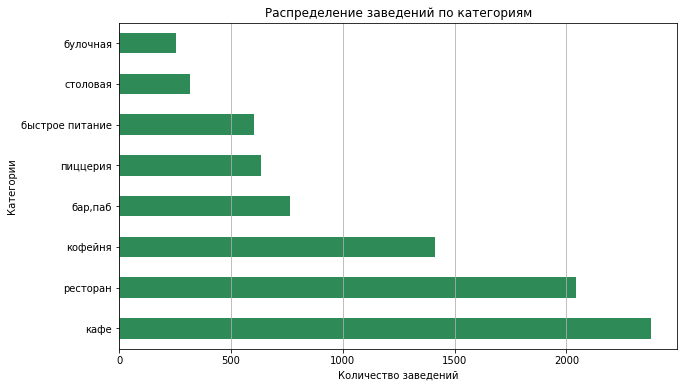

In [27]:
# Задаём размер графика
plt.figure(figsize=(10, 6))

rest_df['category'].value_counts().plot(
                   kind='barh',
                   rot=0,
                   legend=False,
                   color='seagreen',
                   title='Распределение заведений по категориям')
        
# Настраиваем оформление графика
plt.xlabel('Количество заведений')
plt.ylabel('Категории')
# Добавляем сетку по оси x 
plt.grid(axis='x')

# Выводим график
plt.show()

Распределение заведений по категориям наглядно продемонтрировано на линейчатой диаграмме

---
<a id="распределение-по-районам"></a>
### Задача 2

#### Исследуем распределение количества заведений по административным районам Москвы:

In [28]:
display('Распределение заведений по административным районам Москвы:')
display(rest_df.groupby('district')['id'].count().sort_values(ascending=False))

'Распределение заведений по административным районам Москвы:'

district
Центральный административный округ         2242
Северный административный округ             898
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: id, dtype: int64

Text(50.999999999999986, 0.5, 'Районы г.Москва')

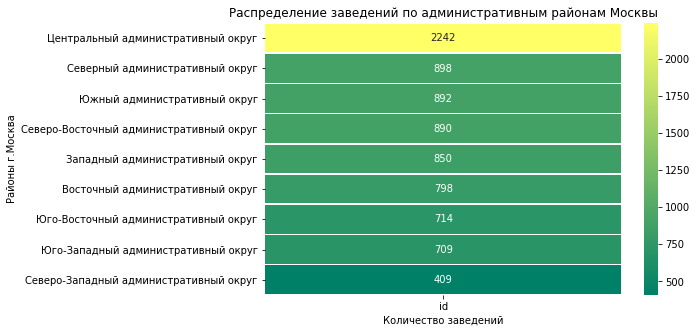

In [29]:
plt.figure(figsize=(8, 5))

df=pd.DataFrame(rest_df.groupby('district')['id'].count().sort_values(ascending=False)) 
sns.heatmap(df, annot=True, fmt='d', linewidths=0.5, cmap='summer')

plt.title('Распределение заведений по административным районам Москвы')
plt.xlabel('Количество заведений')
plt.ylabel('Районы г.Москва')

Из распределения по районам Москвы, заметно, что **большая часть заведений (2242) расположена в Центральном административном округе**. Наименьшее число заведений (409), с разницей примерно в два раза по сравнению с прочими районами, находится в Северо-Западном административном округе. Остальные районы характеризуются примерно одинаковым распределением - в количестве 700-900 заведений общественного питания на округ.

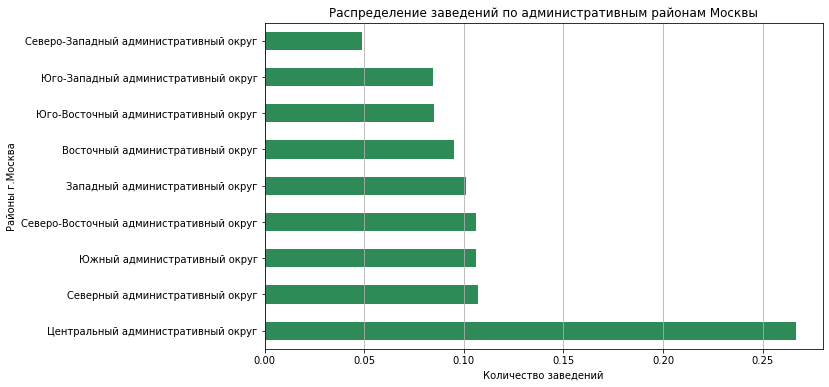

In [30]:
# Задаём размер графика
plt.figure(figsize=(10, 6))

# Построим линейчатую диаграмму распределения по районам в долевых соотношениях
rest_df['district'].value_counts(normalize=True).plot(
                   kind='barh',
                   rot=0,
                   legend=False,
                   color='seagreen',
                   title='Распределение заведений по административным районам Москвы')
        
# Настраиваем оформление графика
plt.xlabel('Количество заведений')
plt.ylabel('Районы г.Москва')
# Добавляем сетку графика
plt.grid(axis='x')

# Выводим график
plt.show()

Более наглядно распределение продемонстрировано на линейчатой диаграмме в долевом соотношении по количеству заведений

Так как большая часть заведений находится в Центральном административном округе Москвы, рассмотрим отдельно распределение заведений каждой категории в этом районе.

#### Изучаем распределение заведений в Центральном административном округе в разрезе категорий

In [31]:
# Отфильтруем данные по изучаемому району
filtered_df = rest_df[rest_df['district'] == 'Центральный административный округ']

# Выведем информацию о количестве заведений в Центральном административном округе по категориям
display('Количество заведений в Центральном административном округе в разрезе категорий')
display(filtered_df.groupby('category')['id'].count().sort_values(ascending=False))

'Количество заведений в Центральном административном округе в разрезе категорий'

category
ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: id, dtype: int64

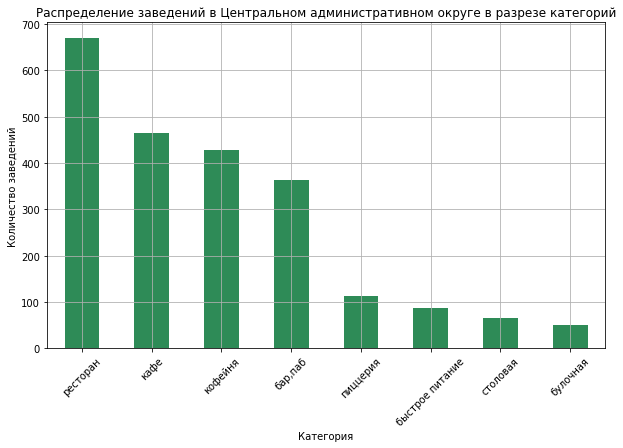

In [32]:
# Задаём размер графика
plt.figure(figsize=(10, 6))

filtered_df['category'].value_counts().plot(
                   kind='bar',
                   rot=45,
                   legend=False,
                   color='seagreen',
                   title='Распределение заведений в Центральном административном округе в разрезе категорий')
        
# Настраиваем оформление графика
plt.xlabel('Категория')
plt.ylabel('Количество заведений')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

По визуализации распределения заведений видно, что **наиболее в центре распространены рестораны (670 заведений), чуть меньше - кафе, кафейни и бары (в количестве 364 - 464 заведений). И в разы меньше - пиццерии, бытро, столовые и булочные (113-50 заведений)**. 

**Можно заметить**, что наибольшей популярностью в центральной части города пользуются заведения более высокого класса обслуживания, предоставляющие зачастую не только гастрономические услуги, но и создающие атмосферу отдыха. Помимо того, можно предположить, что аренда помещений под заведения в центре обходится дороже, и более целесообразно открывать заведения с более высоким чеком для окупаемости затрат. 

---
<a id="соотношение-сетевых"></a>
### Задача 3

#### Изучим соотношение сетевых и несетевых заведений

In [33]:
# Проверяем распределение данных по значениям в столбце chain в долевых соотношениях
print('Отношение сетевых и несетевых заведений в долях:')
print(rest_df['chain'].value_counts(normalize=True))

Отношение сетевых и несетевых заведений в долях:
0    0.618662
1    0.381338
Name: chain, dtype: float64


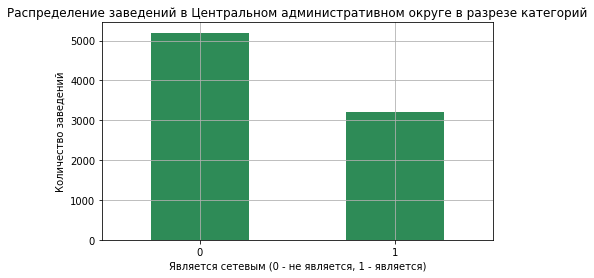

In [34]:
# Задаём размер графика
plt.figure(figsize=(7, 4))

rest_df['chain'].value_counts().plot(
                   kind='bar',
                   rot=0,
                   legend=False,
                   color='seagreen',
                   title='Распределение заведений в Центральном административном округе в разрезе категорий')
        
# Настраиваем оформление графика
plt.xlabel('Является сетевым (0 - не является, 1 - является)')
plt.ylabel('Количество заведений')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Из вычисленных данных видно, что **несетевых заведений значительно больше**. Это интересно, поскольку сетевой бизнес предлагает уже знакомый бренд, готовые решения под ключ и часто закупки оборудования и товаров по более низким ценам. Однако за счет единого для всех заведений сети стандарта, сетевое заведение лишается уникальности, часто возможности создавать уникальное меню и атмосферу, которые могут привлекать и удерживать клиентов. Помимо этого, вероятно, для бизнеса будет проще и дешевле открыть уникальное заведение, чем создать и маштабировать франшизу.

#### Изучим соотношение сетевых и несетевых заведений в разрезе категорий

In [35]:
# Построим сводную таблицу с распределением сетевых и несетевых заведений по категориям
pivot_chain = pd.pivot_table(rest_df,
                           index='category',
                           columns='chain',
                           values='id',
                           aggfunc='count')
# Выведем сводную таблицу 
display('Количество сетевых и несетевых заведений по категориям')
display(pivot_chain)
display('0 - не является сетевым, 1 - является сетевым')

'Количество сетевых и несетевых заведений по категориям'

chain,0,1
category,,
"бар,паб",596,169
булочная,99,156
быстрое питание,371,232
кафе,1598,779
кофейня,693,720
пиццерия,303,330
ресторан,1311,730
столовая,227,88


'0 - не является сетевым, 1 - является сетевым'

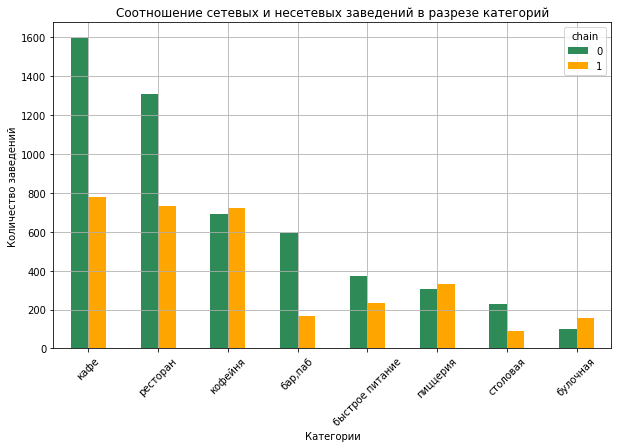

'0 - не является сетевым, 1 - является сетевым'

In [36]:
# Построим столбчатую диаграмму с ссотношением сетевых и несетевых заведений в разрезе категорий
grouped = rest_df.groupby('category')['chain'].value_counts().unstack(fill_value=0)
# Отсортируем значения по убыванию 
grouped_sorted = grouped.sort_values(by=grouped.columns.tolist(), ascending=False)

grouped_sorted.plot(kind='bar',
                   rot=45,
                   legend=True,
                   color=['seagreen', 'orange'],
                   title='Соотношение сетевых и несетевых заведений в разрезе категорий',
                   figsize=(10,6))
        
# Настраиваем оформление графика
plt.xlabel('Категории')
plt.ylabel('Количество заведений')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()
display('0 - не является сетевым, 1 - является сетевым')

Как мы видим из диаграммы, **наибольшее число сетевых заведений присутствует среди кафе, ресторанов и кофеин**. Но в данном случае, это скорее связано с их численным преобладанием среди всех заведений в целом. 

Но интересно заметить, что в категориях **кофейни, пиццерия и булочные (пекарни), сетевые заведения преобладают над несетевыми**. Хотя и с небольшим отрывом. Вероятно, внутри этих категорий заведений, франшиза наиболее распространена. И вероятно, более доступна и окупаема. 

***Отдельно посчитаем долю сетевых заведений по категориям***

In [37]:
# Считаем количество всех заведений по категориям
total_count = rest_df.groupby('category')['id'].count()

# Отфильтруем данные по принадлежности к сетям, оставим только сетевые
filter_df = rest_df[rest_df['chain'] == 1]
# Считаем количество сетевых заведений
count_not_chain = filter_df.groupby('category')['id'].count()

share_of_chain = round(count_not_chain / total_count, 2)
display(share_of_chain.sort_values(ascending=False))

category
булочная           0.61
пиццерия           0.52
кофейня            0.51
быстрое питание    0.38
ресторан           0.36
кафе               0.33
столовая           0.28
бар,паб            0.22
Name: id, dtype: float64

Получаем аналогичный результат, где видно, что **среди булочных(61%), пиццерий(52%) и кофеен(51%) преобладают сетевые заведения**.

---
<a id="количество-мест"></a>
### Задача 4


#### Исследуем количество посадочных мест в заведениях

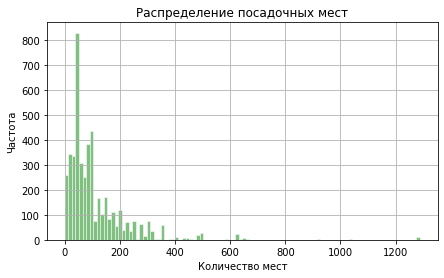

In [38]:
# Задаём размер графика
plt.figure(figsize=(7, 4))

# Отфильтруем значения с индикаторм, где были пропуски
fil_df = rest_df[rest_df['seats'] != 0]

# Строим гистограмму с помощью pandas через plot(kind='hist')
fil_df['seats'].plot(
                kind='hist', 
                bins=100, 
                alpha=0.5,
                color='green',
                edgecolor='white',
                rot=0)

# Настраиваем оформление графика
plt.title('Распределение посадочных мест')
plt.xlabel('Количество мест')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

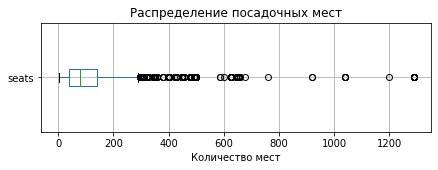

In [39]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
fil_df.boxplot(column='seats', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение посадочных мест')
plt.xlabel('Количество мест')

# Выводим график
plt.show()

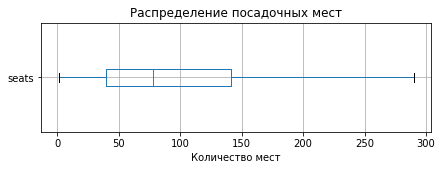

In [40]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
fil_df.boxplot(column='seats', vert=False, showfliers=False) # Исключим выбросы для большей детализации

# Добавляем заголовок и метки оси
plt.title('Распределение посадочных мест')
plt.xlabel('Количество мест')

# Выводим график
plt.show()

На визуализациях наблюдается **правосимметричное распределение данных**. Диаграмма размаха показывает **большое число выбрасов**. **Основная часть данных находится в диапозоне от 40 до 140 мест**. 

В исходных данных нет информации, где располагаются места: внутри заведения, снаружи или это обобщенные площадки нескольких заведений на футкорте. Вероятно, выбросы могли возникнуть из-за неверного расчета мест относительно заведения. 

In [41]:
# Расчитаем медиану количества мест для разных категорий заведений
median = fil_df.groupby('category')['seats'].median().sort_values(ascending=False)
display(median)

category
ресторан           90
бар,паб            84
кофейня            80
столовая           80
быстрое питание    75
кафе               60
пиццерия           56
булочная           51
Name: seats, dtype: int64

Медиана демонстрирует **наиболее типичное количество посадочных мест для заведений**, так как она устойчива к выбросам и хорошо отражает центральное значение в случае неравномерного распределения данных. Судя по значению медиан, **большее количество мест находится в ресторанах**, что вероятно, связано с их площадью и масштабом, **а наименьшее - у миниатюрной булочной**. 

Но значения медиан довольно большие для числа посадочных мест обычного заведения, поэтому опять же требуется уточнение где располагаются места: внутри заведения, снаружи или это обобщенные площадки нескольких заведений. 

***Проверка гипотезы пустых значений***

Ранее у нас возникла гипотеза, что пропущенные значения в столбце `seats` может быть связана с тем, что часть заведений работают по типу "еда на вынос" или "кофе с собой". 

Проверим гипотезу, отобрав индикаторные значения столбца `seats` и выведем топ-15 самых распространенных заведений с отсутствующим значением количества мест. Выведем их названия, чтобы понять, могут ли они подходить под гипотезу. 

In [42]:
# Отфильтруем данные и сгруппируем по названию заведений
filt_df = rest_df[rest_df['seats'] == 0]
seats_group = filt_df.groupby('name')['id'].count()

display('Индикаторные значения')
display(seats_group.sort_values(ascending=False).head(15))

'Индикаторные значения'

name
кафе                116
яндекс лавка         38
шоколадница          37
cofix                30
шаурма               25
буханка              23
cofefest             22
one price coffee     21
кофепорт             19
чайхана              19
drive café           18
prime                17
домино'с пицца       16
столовая             14
додо пицца           13
Name: id, dtype: int64

По итогу, можно сказать, что **гипотеза частично подтвердилась**, так как среди названий присутствуют Яндекс Лавка, много кофеин и шаурма, которые вполне могут не иметь посадочных мест. Но также есть пиццерии, столовые, чайхана - где наличие мест более вероятно, а следовательно данные о них отсутствуют по другим причинам. И есть 116 кафе, не имеющих брендового названия и данных.

---
<a id="рейтинги-заведений"></a>
### Задача 5

#### Изучим распределение средних рейтингов по категориям заведений

In [43]:
# Расчитаем усредненные рейтинги по категориям заведений
avg_rating = rest_df.groupby('category')['rating'].mean().sort_values(ascending=False)
display(avg_rating)

category
бар,паб            4.387712
пиццерия           4.301264
ресторан           4.290348
кофейня            4.277282
булочная           4.269020
столовая           4.211429
кафе               4.124274
быстрое питание    4.050249
Name: rating, dtype: float32

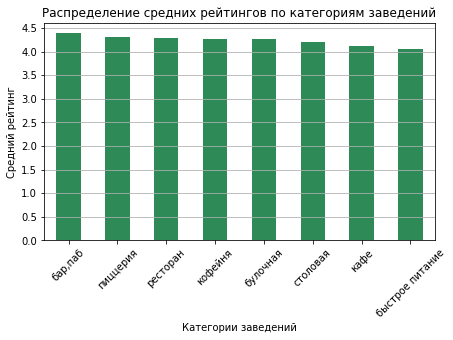

In [44]:
# Задаём размер графика
plt.figure(figsize=(7, 4))

# Построим диаграмму с распределением средних рейтингов по категориям заведений
avg_rating.plot(
                kind='bar',
                rot=45,
                legend=False,
                color='seagreen',
                title='Распределение средних рейтингов по категориям заведений')

# Задаем деления оси y
plt.yticks([0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5])
# Настраиваем оформление графика
plt.xlabel('Категории заведений')
plt.ylabel('Средний рейтинг')
# Добавляем сетку графика
plt.grid(axis='y')

# Выводим график
plt.show()

В результате изучения рейтингов, мы видим, что **усредненные значения рейтингов для разных категорий заведений** общественного питания **не имеют значимых различий и лежат в диапозоне от 4.0 до 4.4**. Это может означать, что заведения из разных категорий не являются конкурентами друг друга, и их оценка рассматривается только в своей категориальной группе. **Самые высокие оценки наблюдаются у баров и пиццерий**

---
<a id="рейтинги-цены"></a>
### Задача 6

#### Исследуем подробнее  рейтинги заведений относительно других данных

Рассмотрим связь величины рейтинга с категорией, положением (административный район Москвы), статусом сетевого заведения, количеством мест, ценовой категорией и признаком, является ли заведения круглосуточным

In [45]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = rest_df[['category', 'district', 'chain', 'seats', 'price', 'is_24_7', 'rating']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['chain', 'seats', 'rating']
Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.310473
category,0.198815
district,0.189453
is_24_7,0.161010
chain,0.118785
seats,0.000000


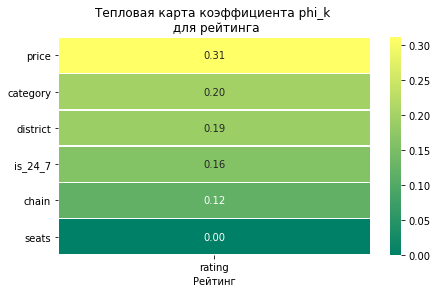

In [46]:
# Для большей визуализации добавим тепловую карту по расчитанной матрице
plt.figure(figsize=(7, 4))

data_heatmap=correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

sns.heatmap(data_heatmap, 
            annot=True,
            fmt='.2f',
            linewidths=0.5,
            cmap='summer')

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для рейтинга')
plt.xlabel('Рейтинг')
plt.show()

**Самая значительная связь (0.30) наблюдается у рейтинга с ценовой категорией заведения**. Так как сам коэффициент `phi_k` не дает нам представление о характере связи, а только сообщает о ее наличии - исследуем связь подробнее.

#### Изучим подробнее взаимосвязь ценовой категории заведения с рейтингом

In [47]:
# Вспомним, какие значения хранятся в столбце price
display(rest_df['price'].unique())

array([-1, 'выше среднего', 'средние', 'высокие', 'низкие'], dtype=object)

Значение -1 является индикатором пропусков, замененных при предобработке данных. Отфильтруем это значение.

In [48]:
# Отфильтруем значения с индикатором, где были пропуски
price_df = rest_df[rest_df['price'] != -1]

In [49]:
# Используем метод describe() чтобы сравнить рейтинги по категориям заведений

rating_inf = price_df.groupby('price')['rating'].describe()
display(rating_inf)

,count,mean,std,min,25%,50%,75%,max
price,,,,,,,,
высокие,478.0,4.436611,0.314197,1.0,4.3,4.4,4.6,5.0
выше среднего,564.0,4.386347,0.223507,2.9,4.3,4.4,4.5,5.0
низкие,156.0,4.173077,0.372671,2.6,4.0,4.2,4.4,5.0
средние,2117.0,4.297874,0.295653,1.6,4.2,4.3,4.4,5.0


Из получившихся данных, можно заметить, что среднее значение рейтинга и медиана у разных ценовых категорий практически совпадают, что говорит об отсутствии выбросов. Также эти значения у разных ценовых категорий схожи между собой. Что означает **отсутствие значимой связи**. 

Если обратить внимание на **размах данных (max-min значения рейтинга)**, то можно заметить, что у заведений с **высокой ценовой категорией** наибольший размах и, следовательно, заведения в этой группе могут сильно отличаться по качеству и удовлетворению ожиданий у клиентов. А заведения **выше среднего**, наоборот имеют наименьший разброс, что может говорить о большем единооброазии заведений в этой категории.

**У рейтинга обнаружены слабо выраженные связи с имеющимися в датасете данными**. Возможно следует провести опросы среди клиентов заведений и уточнить, что влияет на их оценку. И по результатам опроса изучить те характеристики, которые будут выявлены.

---
<a id="популярные-сети"></a>
### Задача 7

#### Изучим популярные сети заведений общественного питания в Москве

In [50]:
# Сгруппируем данные по названию
name_group = rest_df.groupby('name')['id'].count()

display('ТОП-15 популярных сетей в г. Москва')
display(name_group.sort_values(ascending=False).head(15))

'ТОП-15 популярных сетей в г. Москва'

name
кафе                                   188
шоколадница                            120
домино'с пицца                          77
додо пицца                              74
one price coffee                        72
яндекс лавка                            69
cofix                                   65
prime                                   50
хинкальная                              44
шаурма                                  43
кофепорт                                42
кулинарная лавка братьев караваевых     39
теремок                                 38
чайхана                                 37
ресторан                                34
Name: id, dtype: int64

Вероятно, name "кафе" и "ресторан" - это не название сети, а отдельные кафе и рестораны, не имеющие брендового названия или бренд, отсутствующий в данных, поэтому для чистоты исследования, их следует исключить из выборки. 

In [51]:
# Исключим из выборки небрендовые кафе и рестораны
fil_group = rest_df[(rest_df['name'] != 'кафе') & (rest_df['name'] != 'ресторан')]

# Считаем количество заведений, средний рейтинг и выводим категорию заведения
name_group = fil_group.groupby('name').agg({'id': 'count', 'rating': 'mean', 'category':'first'})

display('ТОП-15 популярных сетей в г. Москва')
display(name_group.sort_values(by='id', ascending=False).head(15))

'ТОП-15 популярных сетей в г. Москва'

,id,rating,category
name,,,
шоколадница,120,4.177500,кофейня
домино'с пицца,77,4.171429,пиццерия
додо пицца,74,4.286487,пиццерия
one price coffee,72,4.069445,кофейня
яндекс лавка,69,3.872464,ресторан
cofix,65,4.075385,кофейня
prime,50,4.116000,ресторан
хинкальная,44,4.322727,быстрое питание
шаурма,43,3.909302,быстрое питание


В ТОП-15 самых популярных сетей заведений общественного питания Москвы попали все виды категорий, кроме баров и столовых. Лидирующие позиции занимают кофейни, пиццерии и рестораны (50-120 заведений). **Самую высокую позицию занимает сеть кофеин "Шоколадница" с количеством 120 заведений, что почти в двое больше остальных сетей**. 

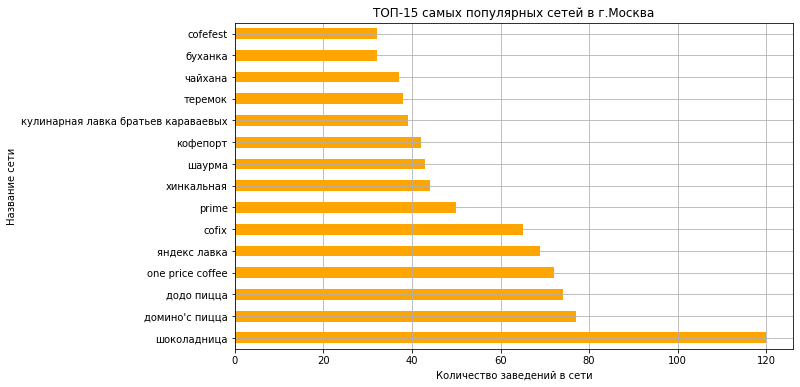

In [52]:
plot_top = fil_group.groupby('name')['id'].count().sort_values(ascending=False).head(15)

# Задаём размер графика
plt.figure(figsize=(10, 6))

# Построим линейчатую диаграмму
plot_top.plot(
                kind='barh',
                rot=0,
                legend=False,
                color='orange',
                title='ТОП-15 самых популярных сетей в г.Москва')

# Настраиваем оформление графика
plt.xlabel('Количество заведений в сети')
plt.ylabel('Название сети')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Визуализация хорошо демонстрирует распределение данных в ТОП-15 популярных сетей

---
<a id="средние-чеки"></a>
### Задача 8

#### Изучим вариацию среднего чека заведения (столбец middle_avg_bill) в зависимости от района Москвы

In [53]:
# Отфильтруем значения-индикаторы, где были пропуски
bill_df = rest_df[rest_df['middle_avg_bill'] != -1]

display('Распределение среднего чека заведений по административным районам Москвы:')
display(bill_df.groupby('district')['middle_avg_bill'].mean().sort_values(ascending=False))

'Распределение среднего чека заведений по административным районам Москвы:'

district
Центральный административный округ         1191.057547
Западный административный округ            1053.225490
Северный административный округ             927.959627
Южный административный округ                834.398089
Северо-Западный административный округ      822.222930
Восточный административный округ            820.626923
Юго-Западный административный округ         792.561702
Северо-Восточный административный округ     716.611296
Юго-Восточный административный округ        654.097938
Name: middle_avg_bill, dtype: float64

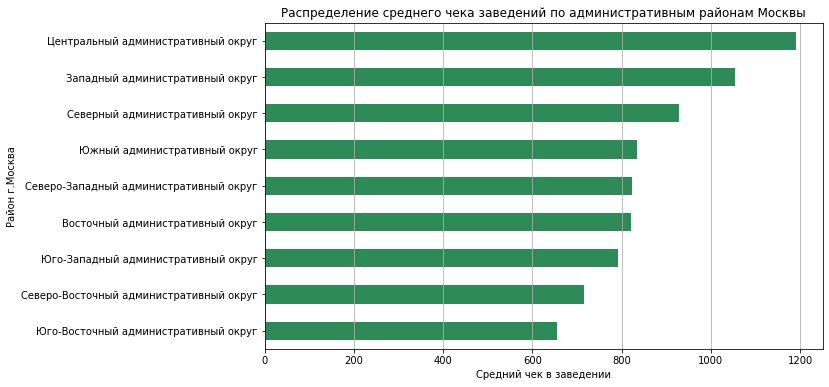

In [54]:
plot_top = bill_df.groupby('district')['middle_avg_bill'].mean().sort_values(ascending=True)

# Задаём размер графика
plt.figure(figsize=(10, 6))

# Построим линейчатую диаграмму
plot_top.plot(
                kind='barh',
                rot=0,
                legend=False,
                color='seagreen',
                title='Распределение среднего чека заведений по административным районам Москвы')

# Настраиваем оформление графика
plt.xlabel('Средний чек в заведении')
plt.ylabel('Район г.Москва')
# Добавляем сетку графика
plt.grid(axis='x')

# Выводим график
plt.show()

---


Сопоставим с информацией о расположении районов относительно центра:

1. **Центральный** (ЦАО) — 0 км, это и есть исторический и административный центр.
2. **Северный** (САО) — находятся вплотную к центру.
3. **Южный** (ЮАО) — очень близок к ядру города.
4. **Северо-Восточный** (СВАО) — граничит с районами центра.
5. **Восточный** (ВАО) — примыкают к центру, но основная часть округа смещена к востоку.
6. **Юго-Восточный** (ЮВАО) — находится рядом с центром, но промзоны и крупные жилые массивы сильно удалены.
7. **Западный** (ЗАО) — примыкает к Арбату, однако округ сильно вытянут на запад.
8. **Юго-Западный** (ЮЗАО) — считается одним из самых протяженных в сторону окраин.
9. **Северо-Западный** (СЗАО) — самый «удаленный» из списка, так как он почти не имеет общей границы с малым центром

Исходя их полученных данных, **чем ближе к центру расположен район, тем выше средник чек в заведениях**. Наиболее высокие ценники у Центрального (АО) - 1191 р., у Западного(АО) - 1053 р., вероятно из-за примыкания к Арбату и у Северного (АО) - 927 р. т.к он находится вплотную к центру.

---

### Промежуточный вывод

#### Оценка категории заведения

- **Самыми распространенными заведениями в Москве являются кафе (28%), рестораны (24%) и кофейни (17%)**.
- Наименее полулярны бары, пиццерии и кафе бытрого питания. Их доля вальируется в 7-9% и количестве 600-800 заведений.
- Самыми непопулярными оказались столовые (315 заведений) и булочные (255 заведений). На их долю приходится 3-4%

- **Самые высокие оценки** наблюдаются у **баров и пиццерий**, но у всех заведений **усредненные значения рейтингов** не имеют значимых различий и лежат **в диапозоне от 4.0 до 4.4**
- **Рейтинг имеет наибольшую связь с ценовой категорией заведения**. Анализ размаха данных выявил, что заведения с **высокой ценовой категорией** имеют **больший разброс данных в рейтинговой оценке**, вероятно из-за завышенных ожиданий у клиентов. При этом заведения с ценовой категорий **выше среднего** имеют **самые стабильные ретинги с наименьшим размахом**, вероятно являясь более доступными по цене и вызывающие меньше завышенных ожиданий. 

- **Количество посадочных мест в заведениях находится в диапозоне от 40 до 140 мест**. Данные показывают, что в кафе посадочных мест меньше, по сравнению с ресторанами, барами и пиццериями. Но в данных содержится **много аномальных значений**, предположительно связанных с наличием данных о **футкортах, где общие посадочные** места для нескольких заведений. 

#### Оценка расположения заведения
- Из распределения по районам Москвы, заметно, что **большая часть заведений (2242) расположена в Центральном административном округе**. Остальные районы характеризуются примерно одинаковым распределением - в количестве 700-900 заведений общественного питания на округ. За исключением Северо-Западного (АО), где числится 409 заведений
- **В центре** больше всего распространены **рестораны (670 заведений), чуть меньше - кафе, кафейни и бары (в количестве 364 - 464 заведений)**. И в разы меньше - пиццерии, бытро, столовые и булочные (113-50 заведений). 
- **Выявлена связь: чем ближе к центру расположен район, тем выше средник чек в заведениях**. Наиболее высокие ценники у **Центрального (АО) - 1191 р., у Западного(АО) - 1053 р.**, вероятно из-за примыкания к Арбату и у **Северного (АО) - 927 р.** т.к он находится вплотную к центру.

#### Сеть или оригинальное заведение

- **Несетевых заведений значительно больше**. Их доля составляет 62% от всех заведений
- Среди **булочных(61%), пиццерий(52%) и кофеен(51%) преобладают сетевые заведения**.
- В ТОП-15 самых популярных сетей **лидирующие позиции занимают кофейни, пиццерии и рестораны** (50-120 заведений). 
- **Самую высокую позицию занимает сеть кофеин "Шоколадница"** с количеством 120 заведений, что почти в двое больше остальных сетей.

<a id="итоговый-вывод"></a>
## 4. Итоговый вывод и рекомендации

По результатам проведённого исследовательского анализа данных сформулируйте итоговый вывод и рекомендации для заказчика. Старайтесь акцентировать внимание на ключевых моментах исследования.

В ходе исследования проанализировали **данные 8406 заведений общественного питания** Москвы за лето 2022 года. Данные включали информацию о заведениях, такую как: название, адрес, расположение, рейтинг, принадлежность к сети, количесвто посадочных мест, часы работы и информацию о среднем чеке в заведжении. **Акцент исследования был направлен на поиск оптимального варианта для открытия нового заведения** в г.Москва по категории, расположению, среднему чеку. 

<a id="основные-выводы"></a>
### 4.1 Основные выводы:
1. **Категория заведения:** 
* В Москве больше всего кафе (28%), ресторанов (24%) и кофейн (17%). 
* **Самые высокие рейтинги** у баров и пиццерий, но усредненный ретинг всех заведений лежит в диапозоне от 4.0 до 4.4. Наибольшую связь рейтинг имеет с ценовой категорией заведения. Заведения с высокой ценовой категорией имеют больший разброс данных в рейтинговой оценке, вероятно из-за завышенных ожиданий у клиентов. При этом заведения с ценовой категорий выше среднего имеют самые стабильные ретинги с наименьшим размахом, вероятно являясь более доступными по цене и вызывающие меньше завышенных ожиданий. 
* **Количество посадочных мест** в заведениях находится в диапозоне от 40 до 140 мест. Данные показывают, что в кафе посадочных мест меньше, по сравнению с ресторанами, барами и пиццериями. Но в данных содержится много аномальных значений, предположительно связанных с наличием данных о футкортах, где общие посадочные места для нескольких заведений. 

2. **Расположение заведения:**
* Большая часть заведений (2242) расположена в Центральном АО. В ближлежащих к центру райнах находятся около 900 заведений. Самыми распространенными в центре явялются рестораны (670 заведений), чуть меньше - кафе, кафейни и бары (в количестве 364 - 464 заведений). чем ближе к центру расположен район, тем выше средник чек в заведениях. Наиболее высокие ценники у Центрального АО - 1191 р., у Западного АО - 1053 р., и у Северного АО - 927 р.

3. **Сеть или оригинальное заведение:**
* Среди заведений больше несетевых, оригинальных мест (62%). При этом для булочных(61%), пиццерий(52%) и кофеен(51%) более характерен сетевой характер. Лидирующую позицию самых популярных сетей с большим отрывом занимает сеть кофеен Шоколадница, а среди категорий преобладают кофейни, пиццерии и рестораны.

<a id="рекомендации"></a>
### 4.2 Рекомендации на основе анализа:
1. Среди **несетевых заведений** наиболее удачно рассматривать категории ресторан, кафе или бар. Ценятся оригинальные заведения с ценовой категорией выше среднего.  
2. Среди **сетевых заведений** самыми удачными вариантами являются пиццерия или кофейня. Особенно рекомендуется обратить внимание на первые 3 позиции рейтинга сетевых заведений.
3. Рекомендуется рассмотреть **расположение для заведения в близлежащих к центру районах, таких как Северный (АО) или Западный (АО), ближе к Арбату**. Так как у ближлежащих райнов довольно **высокий средний чек** относительно центра и дальних районов, но при этом гораздо **меньшая конкуренция** по сравнению с центром, где самый высокий показатель по количеству заведений. 
4. Если необходимо будет **сократить бюджет на аренде**, то можно рассмотреть **вариант футкора**. И более подробно изучить эту категорию расположения заведений